## Linear regression Practical Implementation

* data analysis
* correlation analysis
* simple linear regression
* train test split
* mse rmse mae r2
* linear regression with ols
* multiple linear regression


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading Dataset

In [3]:
df = pd.read_csv('/Users/thameem/Desktop/thameem/Machine Learning/Data/height-weight.csv')

In [164]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Here 
- weight is -> input feature
- Height -> target feature

## Data Analysis

Understanding relationship before modeling

Text(0, 0.5, 'Height')

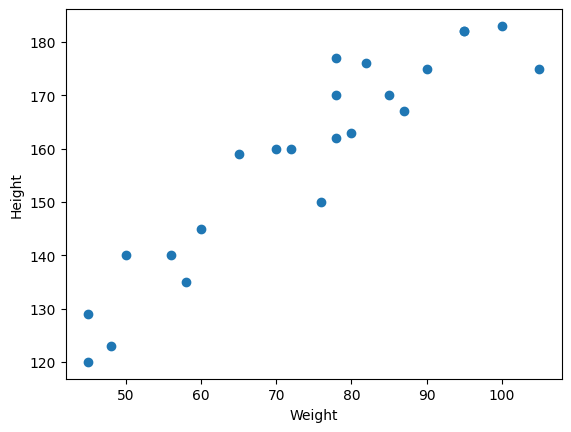

In [165]:
# Scatter plot (relationship checking)

plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

### Observation

- points show upward trend
- as weight increases -> height increases

linear regression is suitable

## Correlation analysis

In [166]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


- correlation close to +1 
  
  - strong positive relationship

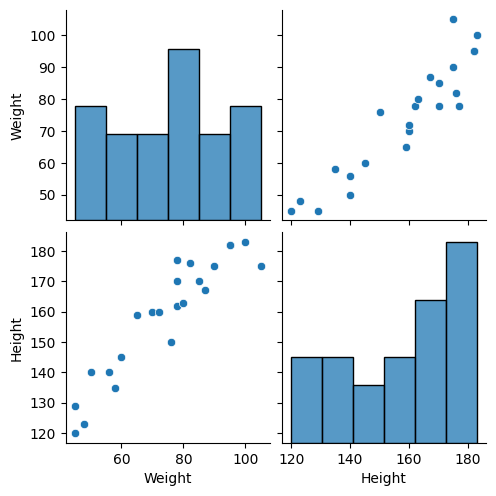

In [167]:
import seaborn as sns
sns.pairplot(df)

## Defining Features and Target

- weight -> independant feature(2D)
- height -> dependant feature(1D)

In [168]:
x = df[['Weight']]
y = df['Height']

- df[] -> series (n,)
- df[[]] -> dataframe (n,1)   -----> this is what scikit-learn expects

In [169]:
np.array(y).shape

(23,)

## Train Test Split

In [170]:
from sklearn.model_selection import train_test_split

In [171]:
x_train, x_test, y_train, y_test = train_test_split(x,y ,test_size=0.25, random_state=42)

### why split 

- Training set → learn patterns
- Test set → evaluate performance

###  what is **test_size** and **random_state** ?


- **test_size=0.25** : it means that 25% of the dataset is used or set for testing , and the remaining 75% used for training model.

- **random_state=42** : this sets a fixed seed for random number generation to ensure reproducibility of results in experiments or simulations.

## Feature Scaling (standardization)

Standardization is a preprocessing technique used to scale feature values to have a mean of 0 and a standard deviation of 1.

### why do we standardize ?

standardization is a crucial step in data preprocessing to enhance the performance and accuracy of machine learning algorithms.

In [172]:
from sklearn.preprocessing import StandardScaler

In [202]:
scalar = StandardScaler()

In [174]:
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

#### Linear Regression (closed-form solution using Normal Equation) is scale-invariant.

In [203]:
# but for simple linear regression (with one feature), scaling is not required
# Create and fit the model without scaling
# model = LinearRegression()
# model.fit(x_train, y_train)

### why we only **transforming** test data without **fitting** ?

1. Avoiding data leakage
2. Consistency

the scaler is fitted only on the training set to prevent leakage and ensure that the scaling of the test set is based solely on the training data.


### Why scale?

- Makes features centered around 0
- Improves numerical stability
- Helps gradient-based algorithms

In [175]:
x_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

## Applying simple linear regression

In [176]:
from sklearn.linear_model import LinearRegression

In [204]:
x_train, x_test, y_train, y_test = train_test_split(x,y ,test_size=0.25, random_state=42)

In [205]:
model = LinearRegression()

### n_job = -1 

LinearRegression(n_job=-1)

- you are instructing the model to use all available cores of your processor to speed up the computation

- but here simple linear regression since only 1 feature , am not used n_job = 1 

In [206]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [207]:
print('coefficient or slope:', model.coef_)
print('intercept:', model.intercept_)

coefficient or slope: [1.04792503]
intercept: 80.5268451262254


### Plotting the training data best fit line

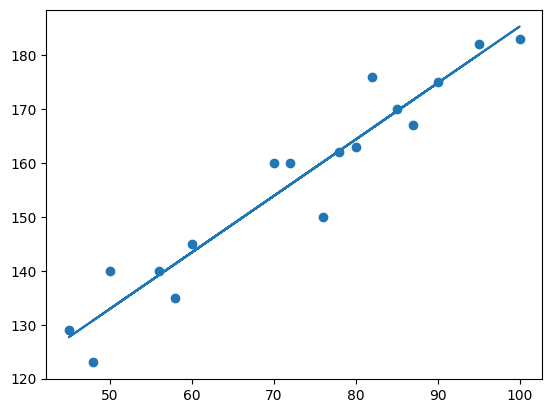

In [208]:
plt.scatter(x_train, y_train)
plt.plot(x_train,model.predict(x_train))

### Prediction of Dataset

- predicted height output =. intercept + coeff_(weights)
- example : y_pred_test = 156.470 + 17.29(x_test)

In [209]:
### Prediction for test data
y_predict = model.predict(x_test)

In [210]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [211]:
mse = mean_squared_error(y_test,y_predict)
mae = mean_absolute_error(y_test,y_predict)
score= r2_score(y_test,y_predict)
rmse = np.sqrt(mse)

### mean absolute error

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

In [212]:
print(mae)
# Lower the MAE value (near to zero) -> better the model performance

9.66512588679501


#### Lower the MAE value (near to zero) -> better the model performance
- An MAE of 0 indicates a perfect fit

### mean squared error

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
$$

In [213]:
print(mse)

114.84069295228699


#### Lower the MSE value (near to zero) -> better the model performance
- An MSE of 0 indicates a perfect fit

### root mean squared error

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2}
$$

- or we can say

$$
RMSE = \sqrt{MSE}
$$

In [186]:
print(rmse)

10.716374991212605


#### Lower the RMSE value (near to zero) -> better the model performance
- An RMSE of 0 indicates a perfect fit

### R square

Formula

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

where:

$$
SS_{res} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

and 

$$
SS_{tot} = \sum_{i=1}^{n} (y_i - \bar{y})^2
$$

- R^2	=	coefficient of determination
- SSr	=	sum of squares of residuals
- SSt	=	total sum of squares

In [187]:

print(score)

0.7360826717981276


#### R square ranges from negagive infinite to 1
- An R square 1 indicates a perfect fit

### Summary 
- MAE, MSE, RMSE -> lower the value indicates better model performance
- R Square -> higher value indicates better model performance

### Adjusted R2 

$$
R^2_{adj} = 1 - \frac{(1 - R^2)(n - 1)}{n - k - 1}
$$

where:

- R2: The R2 of the model
- n: The number of observations
- k: The number of predictor variables

In [214]:
# In our case
r2 = score
n = number_of_observation = len(y_test)
k = number_of_predictors = x_test.shape[1]

In [215]:
# 1 - (1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

1 - (1-r2)*(n-1)/(n-k-1)

0.6701033397476595

### Prediction for new data

In [190]:
model.predict(scalar.transform([[72]]))

/Users/thameem/Desktop/thameem/Machine Learning/.ml/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])

### here we predicted height of a guy with weight 72

- height is 155.97744705

In [191]:
# more prediction

model.predict(scalar.transform([[89]]))

/Users/thameem/Desktop/thameem/Machine Learning/.ml/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([173.7921725])

## OLS Linear Regression

In [192]:
import statsmodels.api as sm

In [193]:
x_train_sm = sm.add_constant(x_train)
model1 = sm.OLS(y_train, x_train_sm).fit()

In [198]:
x_test_sm = sm.add_constant(x_test)
prediction = model1.predict(x_test_sm)
print(prediction)

[162.26499721 162.26499721 127.68347133 180.07972266 148.64197186
 190.55897293]


In [196]:
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Height   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     174.5
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.15e-09
Time:                        15:16:48   Log-Likelihood:                -51.726
No. Observations:                  17   AIC:                             107.5
Df Residuals:                      15   BIC:                             109.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        156.4706      1.310    119.477      0.0

## Residual Analysis

### What is residual 

- The difference between the actual value and the predicted value from a regression model.

### Goals:

- Check model accuracy
- Detect model problems
- Identify outliers
- Validate regression assumptions

## Linear Regression Assumptions
Linear regression assumes:

- Linearity
- Independence of errors
- Homoscedasticity
- Normal distribution of residuals
- No multicollinearity (for multiple features)